In [1]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

# 7. 파이썬으로 DuckDB를 연동하여 EPL데이터를 분석하고 시각화하기

## 7.1 파이썬에서의 DuckDB 환경 구성

In [2]:
## P257
import duckdb

In [3]:
## P258
duckdb.sql("SELECT 'Hello' as 'greeting'").show()

┌──────────┐
│ greeting │
│ varchar  │
├──────────┤
│ Hello    │
└──────────┘



In [4]:
## P258
con_memory = duckdb.connect() ## con = duckdb.connect(':memory:')도 가능

In [5]:
## P258
con_espn = duckdb.connect("./espn.duckdb")

In [ ]:
## P259
con_espn_readonly = duckdb.connect(database = './espn.duckdb', read_only = True)

In [8]:
## P260
duckrel_diamonds = con_memory.read_csv('diamonds.csv');
duckrel_diamonds

┌────────┬───────────┬─────────┬─────────┬────────┬────────┬───────┬────────┬────────┬────────┐
│ carat  │    cut    │  color  │ clarity │ depth  │ table  │ price │   x    │   y    │   z    │
│ double │  varchar  │ varchar │ varchar │ double │ double │ int64 │ double │ double │ double │
├────────┼───────────┼─────────┼─────────┼────────┼────────┼───────┼────────┼────────┼────────┤
│   0.23 │ Ideal     │ E       │ SI2     │   61.5 │   55.0 │   326 │   3.95 │   3.98 │   2.43 │
│   0.21 │ Premium   │ E       │ SI1     │   59.8 │   61.0 │   326 │   3.89 │   3.84 │   2.31 │
│   0.23 │ Good      │ E       │ VS1     │   56.9 │   65.0 │   327 │   4.05 │   4.07 │   2.31 │
│   0.29 │ Premium   │ I       │ VS2     │   62.4 │   58.0 │   334 │    4.2 │   4.23 │   2.63 │
│   0.31 │ Good      │ J       │ SI2     │   63.3 │   58.0 │   335 │   4.34 │   4.35 │   2.75 │
│   0.24 │ Very Good │ J       │ VVS2    │   62.8 │   57.0 │   336 │   3.94 │   3.96 │   2.48 │
│   0.24 │ Very Good │ I       │ VVS1   

In [9]:
## P261
con_memory.sql("""
    FROM read_parquet('diamonds.parquet');
    """)

┌────────┬───────────┬─────────┬─────────┬────────┬────────┬───────┬────────┬────────┬────────┐
│ carat  │    cut    │  color  │ clarity │ depth  │ table  │ price │   x    │   y    │   z    │
│ double │  varchar  │ varchar │ varchar │ double │ double │ int64 │ double │ double │ double │
├────────┼───────────┼─────────┼─────────┼────────┼────────┼───────┼────────┼────────┼────────┤
│   0.23 │ Ideal     │ E       │ SI2     │   61.5 │   55.0 │   326 │   3.95 │   3.98 │   2.43 │
│   0.21 │ Premium   │ E       │ SI1     │   59.8 │   61.0 │   326 │   3.89 │   3.84 │   2.31 │
│   0.23 │ Good      │ E       │ VS1     │   56.9 │   65.0 │   327 │   4.05 │   4.07 │   2.31 │
│   0.29 │ Premium   │ I       │ VS2     │   62.4 │   58.0 │   334 │    4.2 │   4.23 │   2.63 │
│   0.31 │ Good      │ J       │ SI2     │   63.3 │   58.0 │   335 │   4.34 │   4.35 │   2.75 │
│   0.24 │ Very Good │ J       │ VVS2    │   62.8 │   57.0 │   336 │   3.94 │   3.96 │   2.48 │
│   0.24 │ Very Good │ I       │ VVS1   

In [ ]:
## P261
con_espn_readonly.close() ## 연결 종료

## 7.2 파이썬에서 DuckDB쿼리로 다루는 EPL 순위, 경기, 선수 데이터

In [10]:
## p263
con_espn = duckdb.connect("./espn.duckdb")
duckdb_rel_fixtures = con_espn.table('status')
duckdb_rel_fixtures

┌──────────┬──────────────────────────┬─────────┬─────────────────────────────────┐
│ statusId │           name           │  state  │           description           │
│  int64   │         varchar          │ varchar │             varchar             │
├──────────┼──────────────────────────┼─────────┼─────────────────────────────────┤
│        1 │ STATUS_SCHEDULED         │ pre     │ Scheduled                       │
│        2 │ STATUS_IN_PROGRESS       │ in      │ In Progress                     │
│        5 │ STATUS_CANCELED          │ post    │ Canceled                        │
│        6 │ STATUS_POSTPONED         │ post    │ Postponed                       │
│        7 │ STATUS_DELAYED           │ in      │ Delayed                         │
│        8 │ STATUS_SUSPENDED         │ post    │ Suspended                       │
│       23 │ STATUS_HALFTIME          │ in      │ Halftime                        │
│       24 │ STATUS_OVERTIME          │ in      │ Overtime                  

In [11]:
# P264
duckdb_rel_fixtures.explain()

''

In [12]:
## P265
duckdb_list = duckdb_rel_fixtures.fetchall()
duckdb_list

[(1, 'STATUS_SCHEDULED', 'pre', 'Scheduled'),
 (2, 'STATUS_IN_PROGRESS', 'in', 'In Progress'),
 (5, 'STATUS_CANCELED', 'post', 'Canceled'),
 (6, 'STATUS_POSTPONED', 'post', 'Postponed'),
 (7, 'STATUS_DELAYED', 'in', 'Delayed'),
 (8, 'STATUS_SUSPENDED', 'post', 'Suspended'),
 (23, 'STATUS_HALFTIME', 'in', 'Halftime'),
 (24, 'STATUS_OVERTIME', 'in', 'Overtime'),
 (25, 'STATUS_FIRST_HALF', 'in', 'First Half'),
 (26, 'STATUS_SECOND_HALF', 'in', 'Second Half'),
 (27, 'STATUS_ABANDONED', 'post', 'Abandoned'),
 (28, 'STATUS_FULL_TIME', 'post', 'Full Time'),
 (44, 'STATUS_SHOOTOUT', 'in', 'Shootout'),
 (45, 'STATUS_FINAL_AET', 'post', 'Final Score - After Extra Time'),
 (46, 'STATUS_FINAL_AGT', 'post', 'Final Score - After Golden Goal'),
 (47, 'STATUS_FINAL_PEN', 'post', 'Final Score - After Penalties'),
 (51, 'STATUS_FINAL_ABANDONED', 'post', 'Final Score - Abandoned'),
 (53, 'STATUS_END_OF_REGULATION', 'in', 'End of Regulation'),
 (54, 'STATUS_END_OF_EXTRATIME', 'in', 'End of Extra Time')]

In [13]:
## P266
ranking_rel = con_espn.sql("""
    from standings
    join teams using (teamId)
    select teamId, teamRank, displayName, gamesPlayed, wins, ties, losses, points, gf, ga, gd
    where seasonType = 12654
    order by teamRank;
        """)
ranking_rel

┌────────┬──────────┬─────────────────────────┬─────────────┬───────┬───────┬────────┬────────┬────────┬────────┬───────┐
│ teamId │ teamRank │       displayName       │ gamesPlayed │ wins  │ ties  │ losses │ points │   gf   │   ga   │  gd   │
│ int64  │  int64   │         varchar         │    int64    │ int64 │ int64 │ int64  │ int64  │ double │ double │ int64 │
├────────┼──────────┼─────────────────────────┼─────────────┼───────┼───────┼────────┼────────┼────────┼────────┼───────┤
│    364 │        1 │ Liverpool               │          38 │    25 │     9 │      4 │     84 │   86.0 │   41.0 │    45 │
│    359 │        2 │ Arsenal                 │          38 │    20 │    14 │      4 │     74 │   69.0 │   34.0 │    35 │
│    382 │        3 │ Manchester City         │          38 │    21 │     8 │      9 │     71 │   72.0 │   44.0 │    28 │
│    363 │        4 │ Chelsea                 │          38 │    20 │     9 │      9 │     69 │   64.0 │   43.0 │    21 │
│    361 │        5 │ Ne

In [14]:
## P267
ranking_rel = con_espn.sql("""
    from standings
    join teams using (teamId)
    select teamId, teamRank AS 순위, displayName AS 팀, gamesPlayed AS "경기 수",
        wins AS 승, ties AS 무, losses AS 패, points AS 승점, gf AS 득점, ga AS 실점, gd AS 골득실차,
    form AS 최근5겅기, color AS 색상, logoURL AS 로고URL
    where seasonType = 12654
    order by teamRank;
    """)
ranking_rel.df()

,teamId,순위,팀,경기 수,승,무,패,승점,득점,실점,골득실차,최근5겅기,색상,로고URL
0,364,1,Liverpool,38,25,9,4,84,86.0,41.0,45,WLDLD,d11317,https://a.espncdn.com/i/teamlogos/soccer/500/3...
1,359,2,Arsenal,38,20,14,4,74,69.0,34.0,35,DLDWW,e20520,https://a.espncdn.com/i/teamlogos/soccer/500/3...
2,382,3,Manchester City,38,21,8,9,71,72.0,44.0,28,WWDWW,99c5ea,https://a.espncdn.com/i/teamlogos/soccer/500/3...
3,363,4,Chelsea,38,20,9,9,69,64.0,43.0,21,WWLWW,144992,https://a.espncdn.com/i/teamlogos/soccer/500/3...
4,361,5,Newcastle United,38,20,6,12,66,68.0,47.0,21,WDWLL,000000,https://a.espncdn.com/i/teamlogos/soccer/500/3...
5,362,6,Aston Villa,38,19,9,10,66,58.0,51.0,7,LWWWL,660e36,https://a.espncdn.com/i/teamlogos/soccer/500/3...
6,393,7,Nottingham Forest,38,19,8,11,65,58.0,46.0,12,LDDWL,c8102e,https://a.espncdn.com/i/teamlogos/soccer/500/3...
7,331,8,Brighton & Hove Albion,38,16,13,9,61,66.0,59.0,7,WDWWW,0606fa,https://a.espncdn.com/i/teamlogos/soccer/500/3...
8,349,9,AFC Bournemouth,38,15,11,12,56,58.0,46.0,12,DWLLW,f42727,https://a.espncdn.com/i/teamlogos/soccer/500/3...
9,337,10,Brentford,38,16,8,14,56,66.0,57.0,9,WWWLD,f42727,https://a.espncdn.com/i/teamlogos/soccer/500/3...


In [15]:
## P268
ranking_rel.pl()

teamId,순위,팀,경기 수,승,무,패,승점,득점,실점,골득실차,최근5겅기,색상,로고URL
i64,i64,str,i64,i64,i64,i64,i64,f64,f64,i64,str,str,str
364,1,"""Liverpool""",38,25,9,4,84,86.0,41.0,45,"""WLDLD""","""d11317""","""https://a.espncdn.com/i/teamlo…"
359,2,"""Arsenal""",38,20,14,4,74,69.0,34.0,35,"""DLDWW""","""e20520""","""https://a.espncdn.com/i/teamlo…"
382,3,"""Manchester City""",38,21,8,9,71,72.0,44.0,28,"""WWDWW""","""99c5ea""","""https://a.espncdn.com/i/teamlo…"
363,4,"""Chelsea""",38,20,9,9,69,64.0,43.0,21,"""WWLWW""","""144992""","""https://a.espncdn.com/i/teamlo…"
361,5,"""Newcastle United""",38,20,6,12,66,68.0,47.0,21,"""WDWLL""","""000000""","""https://a.espncdn.com/i/teamlo…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
380,16,"""Wolverhampton Wanderers""",38,12,6,20,42,54.0,69.0,-15,"""WLLLD""","""fdb913""","""https://a.espncdn.com/i/teamlo…"
367,17,"""Tottenham Hotspur""",38,11,5,22,38,64.0,65.0,-1,"""LDLLL""","""ffffff""","""https://a.espncdn.com/i/teamlo…"
375,18,"""Leicester City""",38,6,7,25,25,33.0,80.0,-47,"""LWDWL""","""0202fb""","""https://a.espncdn.com/i/teamlo…"


In [16]:
### P268
while True:
    row = ranking_rel.fetchone()
    if row is None:
        break
    print(row)

(364, 1, 'Liverpool', 38, 25, 9, 4, 84, 86.0, 41.0, 45, 'WLDLD', 'd11317', 'https://a.espncdn.com/i/teamlogos/soccer/500/364.png')
(359, 2, 'Arsenal', 38, 20, 14, 4, 74, 69.0, 34.0, 35, 'DLDWW', 'e20520', 'https://a.espncdn.com/i/teamlogos/soccer/500/359.png')
(382, 3, 'Manchester City', 38, 21, 8, 9, 71, 72.0, 44.0, 28, 'WWDWW', '99c5ea', 'https://a.espncdn.com/i/teamlogos/soccer/500/382.png')
(363, 4, 'Chelsea', 38, 20, 9, 9, 69, 64.0, 43.0, 21, 'WWLWW', '144992', 'https://a.espncdn.com/i/teamlogos/soccer/500/363.png')
(361, 5, 'Newcastle United', 38, 20, 6, 12, 66, 68.0, 47.0, 21, 'WDWLL', '000000', 'https://a.espncdn.com/i/teamlogos/soccer/500/361.png')
(362, 6, 'Aston Villa', 38, 19, 9, 10, 66, 58.0, 51.0, 7, 'LWWWL', '660e36', 'https://a.espncdn.com/i/teamlogos/soccer/500/362.png')
(393, 7, 'Nottingham Forest', 38, 19, 8, 11, 65, 58.0, 46.0, 12, 'LDDWL', 'c8102e', 'https://a.espncdn.com/i/teamlogos/soccer/500/393.png')
(331, 8, 'Brighton & Hove Albion', 38, 16, 13, 9, 61, 66.0, 5

In [17]:
## P270
player = "Son Heung-min"
con_espn.execute("""
    FROM players
        JOIN playerStats_2024_EPL USING (athleteId)
    SELECT displayName, displayHeight, displayWeight, dateOfBirth, citizenship,
        positionName, appearances_value, subIns_value, yellowCards_value,
        redCards_value, shotsFaced_value, totalShots_value
    WHERE displayName ILIKE ?;
    """, [player]).df()

,displayName,displayHeight,displayWeight,dateOfBirth,citizenship,positionName,appearances_value,subIns_value,yellowCards_value,redCards_value,shotsFaced_value,totalShots_value
0,Son Heung-Min,"6' 0""",172 lbs,1992-07-08T07:00Z,South Korea,Forward,30,6,1,0,0,55


In [18]:
## P271
playerStats_rel = con_espn.table('playerStats_2024_EPL')
playerStats_rel

┌────────────┬───────┬─────────┬────────┬───────────┬───────────────────┬──────────────┬──────────────────────┬─────────────────────┬───────────────────┬────────────────┬────────────────┬───────────────────┬────────────────┬─────────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────┬─────────────────────┬─────────────────────┐
│ seasonType │ year  │ league  │ teamId │ athleteId │ appearances_value │ subIns_value │ foulsCommitted_value │ foulsSuffered_value │ yellowCards_value │ redCards_value │ ownGoals_value │ goalAssists_value │ offsides_value │ shotsOnTarget_value │ totalShots_value │ totalGoals_value │ shotsFaced_value │ saves_value │ goalsConceded_value │      timestamp      │
│   int64    │ int64 │ varchar │ int64  │   int64   │       int64       │    int64     │        int64         │        int64        │       int64       │     int64      │     int64      │       int64       │     int64      │        int64        │      int64       │      int64

In [19]:
## P272
playerStats_rel.filter('seasonType = 12654')

┌────────────┬───────┬─────────┬────────┬───────────┬───────────────────┬──────────────┬──────────────────────┬─────────────────────┬───────────────────┬────────────────┬────────────────┬───────────────────┬────────────────┬─────────────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────┬─────────────────────┬─────────────────────┐
│ seasonType │ year  │ league  │ teamId │ athleteId │ appearances_value │ subIns_value │ foulsCommitted_value │ foulsSuffered_value │ yellowCards_value │ redCards_value │ ownGoals_value │ goalAssists_value │ offsides_value │ shotsOnTarget_value │ totalShots_value │ totalGoals_value │ shotsFaced_value │ saves_value │ goalsConceded_value │      timestamp      │
│   int64    │ int64 │ varchar │ int64  │   int64   │       int64       │    int64     │        int64         │        int64        │       int64       │     int64      │     int64      │       int64       │     int64      │        int64        │      int64       │      int64

In [20]:
## P272
(playerStats_rel
    .filter('seasonType = 12654')
    .project("""teamId, athleteId, yellowCards_value, redCards_value""")
    .limit(10))

┌────────┬───────────┬───────────────────┬────────────────┐
│ teamId │ athleteId │ yellowCards_value │ redCards_value │
│ int64  │   int64   │       int64       │     int64      │
├────────┼───────────┼───────────────────┼────────────────┤
│    368 │      4946 │                 5 │              0 │
│    367 │      6327 │                 5 │              0 │
│    349 │      7441 │                 0 │              0 │
│    373 │      9426 │                 4 │              1 │
│    331 │     17828 │                 1 │              0 │
│    375 │     17861 │                 0 │              0 │
│    331 │     20975 │                 0 │              0 │
│    373 │     20975 │                 3 │              0 │
│    331 │     26843 │                 1 │              0 │
│    393 │     30377 │                 2 │              0 │
├────────┴───────────┴───────────────────┴────────────────┤
│ 10 rows                                       4 columns │
└───────────────────────────────────────

In [21]:
## P273
playerStats_rel_grouped = (playerStats_rel
    .filter('seasonType = 12654')
    .aggregate("""teamId, sum(yellowCards_value), sum(redCards_value),
                sum(ownGoals_value), sum(goalAssists_value),
                sum(offsides_value), sum(shotsOnTarget_value),
                sum(totalShots_value), sum(saves_value) """)
)
playerStats_rel_grouped.pl()

teamId,sum(yellowCards_value),sum(redCards_value),sum(ownGoals_value),sum(goalAssists_value),sum(offsides_value),sum(shotsOnTarget_value),sum(totalShots_value),sum(saves_value)
i64,"decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]"
382,58,2,2,51,45,201,599,179
349,97,3,0,42,73,192,577,269
368,81,2,0,29,77,131,396,252
393,88,2,0,44,86,156,461,280
363,101,2,0,48,66,194,600,227
…,…,…,…,…,…,…,…,…
359,67,6,0,57,81,174,536,202
301,71,0,4,34,65,137,429,336
376,89,3,0,16,47,99,339,362


In [22]:
## P275
R1 = ranking_rel.set_alias("rel_1")
R2 = playerStats_rel_grouped.set_alias("rel_2")

(R1.join(R2, "rel_1.teamId = rel_2.teamId", how = 'inner')
    .project("""rel_1.teamId, 순위, 팀, 승, 무,
        패, 승점, \"sum(goalAssists_value)\"::int64 as 어시스트,
        \"sum(shotsOnTarget_value)\"::int64 as SOT, 득점::int64 as 골""")).pl()

teamId,순위,팀,승,무,패,승점,어시스트,SOT,골
i64,i64,str,i64,i64,i64,i64,i64,i64,i64
364,1,"""Liverpool""",25,9,4,84,66,216,86
359,2,"""Arsenal""",20,14,4,74,57,174,69
382,3,"""Manchester City""",21,8,9,71,51,201,72
363,4,"""Chelsea""",20,9,9,69,48,194,64
361,5,"""Newcastle United""",20,6,12,66,51,167,68
…,…,…,…,…,…,…,…,…,…
380,16,"""Wolverhampton Wanderers""",12,6,20,42,42,148,54
367,17,"""Tottenham Hotspur""",11,5,22,38,49,183,64
375,18,"""Leicester City""",6,7,25,25,25,106,33


In [23]:
## P276
playerStats_rel_grouped.project("teamId").except_(ranking_rel.project("teamId"))

┌────────┐
│ teamId │
│ int64  │
├────────┤
│    379 │
│    398 │
│    301 │
└────────┘

## 7.3 plotly와 great_tables로 시각화하는 EPL 선수와 팀 성과

In [24]:
## P279
effi_shot = con_espn.sql("""
    from playerStats_2024_EPL
    join teamRoster using (athleteId)
    select athleteId, playerDisplayName, "position",
        (shotsOnTarget_value/totalShots_value).round(2) as shots_efficiency, totalGoals_value
    where playerStats_2024_EPL.seasonType = 12654 and totalGoals_value <> 0
    """).pl()
effi_shot

athleteId,playerDisplayName,position,shots_efficiency,totalGoals_value
i64,str,str,f64,i64
232662,"""Patson Daka""","""Forward""",0.25,1
146679,"""Daniel Muñoz""","""Defender""",0.39,4
265907,"""Marc Guéhi""","""Defender""",0.53,3
265918,"""Maxence Lacroix""","""Defender""",0.14,1
272585,"""Chris Richards""","""Defender""",0.46,1
…,…,…,…,…
129737,"""Michail Antonio""","""Forward""",0.21,1
142055,"""Bobby De Cordova-Reid""","""Forward""",0.38,1
301525,"""Rodrigo Muniz""","""Forward""",0.45,8


In [25]:
## P280
import plotly.express as px

fig = px.scatter(
    effi_shot, x="shots_efficiency", y="totalGoals_value",
    color="position", # 포지션별 색 구분
    hover_data=["playerDisplayName"], # 마우스 오버 시 선수 이름 표시
    title="유효슈팅수 vs 전체골수(24/25 프리미어리그)",
    labels={"shots_efficiency": "유효슈팅 효율", "totalGoals_value": "총 득점수",
        "position": "포지션", "playerDisplayName": "선수 이름"} )

fig.show()

In [26]:
## P282
fouls_per_position = con_espn.sql("""
    from playerStats_2024_EPL
    join teamRoster using (athleteId)
    select "position", foulsCommitted_value
    where playerStats_2024_EPL.seasonType = 12654 and appearances_value <> 0 """).pl()
fouls_per_position

position,foulsCommitted_value
str,i64
"""Midfielder""",16
"""Defender""",7
"""Defender""",2
"""Forward""",4
"""Defender""",9
…,…
"""Defender""",0
"""Midfielder""",1
"""Defender""",27


In [27]:
## P283
fig = px.box(
    fouls_per_position,
    x="position", # 포지션별
    y="foulsCommitted_value", # 파울 수
    title="포지션별 파울 수 분포",
    labels={"position": "포지션", "foulsCommitted_value": "파울 수"})
fig.show()

In [28]:
## P284
posession_per_team = con_espn.sql("""
    from teamStats
    join teams using (teamId)
    join standings using (teamId)
    select teamName: teamRank||'위 '||(teams.displayName), posession: avg(possessionPct).round(1)
    where teamStats.seasonType = 12654 and standings.seasonType = 12654
    group by all""").pl()
posession_per_team

teamName,posession
str,f64
"""20위 Southampton""",48.7
"""11위 Fulham""",52.3
"""10위 Brentford""",47.8
"""18위 Leicester City""",45.3
"""9위 AFC Bournemouth""",48.6
…,…
"""5위 Newcastle United""",51.2
"""2위 Arsenal""",57.0
"""8위 Brighton & Hove Albion""",52.6


In [29]:
## P285
fig = px.bar(
    posession_per_team,
     x="posession", # 가로축: 평균 점유율
    y="teamName", # 세로축: 팀 이름(순위 포함)
    orientation="h", # 가로 막대 설정
    title="팀별 평균 점유율 (2024 시즌)",
    labels={"teamName": "팀 (순위 포함)", "posession": "평균 점유율 (%)"},
    text="posession") # 막대에 점유율 표시

# 텍스트 위치 및 레이아웃 조정
fig.update_traces(textposition="outside")
fig.update_layout(yaxis=dict(categoryorder="total ascending"))
fig.show()

In [30]:
## P286
possession_by_round = con_espn.sql("""
    FROM(FROM teamStats
        join fixtures using (eventId)
        join teams using (teamId)
      select ROW_NUMBER() OVER (partition by teamStats.teamId order by date) AS round,
      displayName, possessionPct
      where teamStats.seasonType = 12654 and
      displayName in ('Manchester City', 'Tottenham Hotspur'))
    pivot (first(possessionPct)
      for displayName in ('Manchester City', 'Tottenham Hotspur'))
    order by 1""").pl()
possession_by_round

round,Manchester City,Tottenham Hotspur
i64,f64,f64
1,51.8,70.5
2,75.2,70.5
3,67.6,65.7
4,53.8,63.7
5,77.2,48.0
…,…,…
34,61.6,38.5
35,63.9,44.5
36,71.8,47.3


In [31]:
## P287
fig = px.line(
    possession_by_round,
    x="round", y=["Manchester City", "Tottenham Hotspur"], # 여러 열을 리스트로 전달
    markers=True, title="Manchester City vs. Tottenham Hotspur 점유율 변화(2024 시즌)",
    labels={"round": "Round",
        "value": "점유율(%)", # wide-form에서 y축 라벨 키는 'value'
        "variable": "팀"} # 범례 제목(자동 생성되는 'variable')
)
# 축 설정
fig.update_layout(legend_title_text="", xaxis=dict(dtick=1))
fig.update_xaxes(range=[0, 39])
fig.update_yaxes(range=[30, 80])
fig.show()

In [32]:
#@ P289
import polars as pl
from great_tables import GT, md, html, loc, style

In [33]:
## P290
ranking_rel = con_espn.sql("""
    from standings
    join teams using (teamId)
    select teamId, teamRank, displayName, gamesPlayed, wins, ties, losses,
        points, gf, ga, gd, form, color, logoURL
    where seasonType = 12654
    order by teamRank; """)
ranking_rel

┌────────┬──────────┬─────────────────────────┬─────────────┬───────┬───────┬────────┬────────┬────────┬────────┬───────┬─────────┬─────────┬──────────────────────────────────────────────────────┐
│ teamId │ teamRank │       displayName       │ gamesPlayed │ wins  │ ties  │ losses │ points │   gf   │   ga   │  gd   │  form   │  color  │                       logoURL                        │
│ int64  │  int64   │         varchar         │    int64    │ int64 │ int64 │ int64  │ int64  │ double │ double │ int64 │ varchar │ varchar │                       varchar                        │
├────────┼──────────┼─────────────────────────┼─────────────┼───────┼───────┼────────┼────────┼────────┼────────┼───────┼─────────┼─────────┼──────────────────────────────────────────────────────┤
│    364 │        1 │ Liverpool               │          38 │    25 │     9 │      4 │     84 │   86.0 │   41.0 │    45 │ WLDLD   │ d11317  │ https://a.espncdn.com/i/teamlogos/soccer/500/364.png │
│    359 │     

In [34]:
## P291
playerStats_rel = con_espn.table('playerStats_2024_EPL')
playerStats_rel_grouped = (playerStats_rel
    .filter('seasonType = 12654')
    .aggregate('''teamId, sum(goalAssists_value), sum(shotsOnTarget_value),
        sum(totalShots_value), max(timestamp) as latest_date'''))
playerStats_rel_grouped

┌────────┬────────────────────────┬──────────────────────────┬───────────────────────┬─────────────────────┐
│ teamId │ sum(goalAssists_value) │ sum(shotsOnTarget_value) │ sum(totalShots_value) │     latest_date     │
│ int64  │         int128         │          int128          │        int128         │      timestamp      │
├────────┼────────────────────────┼──────────────────────────┼───────────────────────┼─────────────────────┤
│    360 │                     31 │                      167 │                   518 │ 2025-06-18 04:51:00 │
│    379 │                     30 │                      136 │                   427 │ 2024-07-13 02:49:22 │
│    331 │                     41 │                      180 │                   529 │ 2025-06-18 04:50:56 │
│    380 │                     42 │                      148 │                   431 │ 2025-06-18 04:51:03 │
│    364 │                     66 │                      216 │                   635 │ 2025-06-18 04:50:59 │
│    393 │         

In [35]:
## P291
R1 = ranking_rel.set_alias("rel_1")
R2 = playerStats_rel_grouped.set_alias("rel_2")

In [36]:
## P292
last_day = (playerStats_rel_grouped.aggregate("max(latest_date)::date").fetchall()[0][0].
    strftime("%Y년 %m월 %d일"))

In [37]:
## P292
ranking_table = (R1.join(R2, 'rel_1.teamId = rel_2.teamId', how = 'inner')
    .project('''teamRank, logoURL, displayName as 팀, gamesPlayed as 경기수, wins as 승, 
        ties as 무, losses as 패, points as 승점, gf::int64 as 득점, ga::int64 as 실점, 
        gd::int64 as 득실차, \"sum(goalAssists_value)\"::int64 as 총어시스트,
        \"sum(shotsOnTarget_value)\"::int64 as 총유효슛, 
        round(득점/경기수, 1) as 경기당득점, round(실점/경기수, 1) as 경기당실점,
        round(총유효슛/경기수, 1) as 경기당유효슛, 
        round(총유효슛/득점, 1) as 득점당유효슛,
        CASE WHEN substr(form, 1, 1) = 'W' THEN 'win.png' 
             WHEN substr(form, 1, 1) = 'D' THEN 'draw.png' ELSE 'lose.png' END as g1,
        CASE WHEN substr(form, 2, 1) = 'W' THEN 'win.png' 
             WHEN substr(form, 2, 1) = 'D' THEN 'draw.png' ELSE 'lose.png' END as g2,
        CASE WHEN substr(form, 3, 1) = 'W' THEN 'win.png' 
             WHEN substr(form, 3, 1) = 'D' THEN 'draw.png' ELSE 'lose.png' END as g3,
        CASE WHEN substr(form, 4, 1) = 'W' THEN 'win.png' 
             WHEN substr(form, 4, 1) = 'D' THEN 'draw.png' ELSE 'lose.png' END as g4,
        CASE WHEN substr(form, 5, 1) = 'W' THEN 'win.png' 
             WHEN substr(form, 5, 1) = 'D' THEN 'draw.png' ELSE 'lose.png' END as g5'''))
ranking_table.pl()

teamRank,logoURL,팀,경기수,승,무,패,승점,득점,실점,득실차,총어시스트,총유효슛,경기당득점,경기당실점,경기당유효슛,득점당유효슛,g1,g2,g3,g4,g5
i64,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,str,str,str,str
1,"""https://a.espncdn.com/i/teamlo…","""Liverpool""",38,25,9,4,84,86,41,45,66,216,2.3,1.1,5.7,2.5,"""win.png""","""lose.png""","""draw.png""","""lose.png""","""draw.png"""
2,"""https://a.espncdn.com/i/teamlo…","""Arsenal""",38,20,14,4,74,69,34,35,57,174,1.8,0.9,4.6,2.5,"""draw.png""","""lose.png""","""draw.png""","""win.png""","""win.png"""
3,"""https://a.espncdn.com/i/teamlo…","""Manchester City""",38,21,8,9,71,72,44,28,51,201,1.9,1.2,5.3,2.8,"""win.png""","""win.png""","""draw.png""","""win.png""","""win.png"""
4,"""https://a.espncdn.com/i/teamlo…","""Chelsea""",38,20,9,9,69,64,43,21,48,194,1.7,1.1,5.1,3.0,"""win.png""","""win.png""","""lose.png""","""win.png""","""win.png"""
5,"""https://a.espncdn.com/i/teamlo…","""Newcastle United""",38,20,6,12,66,68,47,21,51,167,1.8,1.2,4.4,2.5,"""win.png""","""draw.png""","""win.png""","""lose.png""","""lose.png"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
16,"""https://a.espncdn.com/i/teamlo…","""Wolverhampton Wanderers""",38,12,6,20,42,54,69,-15,42,148,1.4,1.8,3.9,2.7,"""win.png""","""lose.png""","""lose.png""","""lose.png""","""draw.png"""
17,"""https://a.espncdn.com/i/teamlo…","""Tottenham Hotspur""",38,11,5,22,38,64,65,-1,49,183,1.7,1.7,4.8,2.9,"""lose.png""","""draw.png""","""lose.png""","""lose.png""","""lose.png"""
18,"""https://a.espncdn.com/i/teamlo…","""Leicester City""",38,6,7,25,25,33,80,-47,25,106,0.9,2.1,2.8,3.2,"""lose.png""","""win.png""","""draw.png""","""win.png""","""lose.png"""


In [38]:
## P293
GT_table = GT(ranking_table.pl(), locale = 'ko')
GT_table

teamRank,logoURL,팀,경기수,승,무,패,승점,득점,실점,득실차,총어시스트,총유효슛,경기당득점,경기당실점,경기당유효슛,득점당유효슛,g1,g2,g3,g4,g5
1,https://a.espncdn.com/i/teamlogos/soccer/500/364.png,Liverpool,38,25,9,4,84,86,41,45,66,216,2.3,1.1,5.7,2.5,win.png,lose.png,draw.png,lose.png,draw.png
2,https://a.espncdn.com/i/teamlogos/soccer/500/359.png,Arsenal,38,20,14,4,74,69,34,35,57,174,1.8,0.9,4.6,2.5,draw.png,lose.png,draw.png,win.png,win.png
3,https://a.espncdn.com/i/teamlogos/soccer/500/382.png,Manchester City,38,21,8,9,71,72,44,28,51,201,1.9,1.2,5.3,2.8,win.png,win.png,draw.png,win.png,win.png
4,https://a.espncdn.com/i/teamlogos/soccer/500/363.png,Chelsea,38,20,9,9,69,64,43,21,48,194,1.7,1.1,5.1,3.0,win.png,win.png,lose.png,win.png,win.png
5,https://a.espncdn.com/i/teamlogos/soccer/500/361.png,Newcastle United,38,20,6,12,66,68,47,21,51,167,1.8,1.2,4.4,2.5,win.png,draw.png,win.png,lose.png,lose.png
6,https://a.espncdn.com/i/teamlogos/soccer/500/362.png,Aston Villa,38,19,9,10,66,58,51,7,48,167,1.5,1.3,4.4,2.9,lose.png,win.png,win.png,win.png,lose.png
7,https://a.espncdn.com/i/teamlogos/soccer/500/393.png,Nottingham Forest,38,19,8,11,65,58,46,12,44,156,1.5,1.2,4.1,2.7,lose.png,draw.png,draw.png,win.png,lose.png
8,https://a.espncdn.com/i/teamlogos/soccer/500/331.png,Brighton & Hove Albion,38,16,13,9,61,66,59,7,41,180,1.7,1.6,4.7,2.7,win.png,draw.png,win.png,win.png,win.png
9,https://a.espncdn.com/i/teamlogos/soccer/500/349.png,AFC Bournemouth,38,15,11,12,56,58,46,12,42,192,1.5,1.2,5.1,3.3,draw.png,win.png,lose.png,lose.png,win.png
10,https://a.espncdn.com/i/teamlogos/soccer/500/337.png,Brentford,38,16,8,14,56,66,57,9,44,181,1.7,1.5,4.8,2.7,win.png,win.png,win.png,lose.png,draw.png


In [39]:
## P294
GT_table = GT_table.tab_header(
    title=md("<h1>2024/25 프리미어리그 순위"),
    subtitle=md(f"<div style='text-align:right'><h2>{last_day} 기준"))
GT_table

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    

In [40]:
## P295
GT_table = (GT_table
    .cols_label(logoURL = '')
    .cols_label(teamRank = '순위')
    .cols_label(g1 = '')
    .cols_label(g2 = '')
    .cols_label(g3 = '')
    .cols_label(g4 = '')
    .cols_label(g5 = '최근')
    .cols_width(cases= {"g1" : '40px', 'g2' : '40px', "g3" : '40px', 'g4' : '40px', 
        "g5" : '40px'})
    .cols_label(총어시스트 = html('총<BR>도움'))
    .cols_label(총유효슛 = html('총<BR>유효슛'))
    .cols_label(경기당득점 = html('경기당<BR>득점'))
    .cols_label(경기당실점 = html('경기당<BR>실점'))
    .cols_label(경기당유효슛 = html('경기당<BR>유효슛'))
    .cols_label(득점당유효슛 = html('득점당<BR>유효슛'))
)
GT_table     

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    

In [41]:
## P296
GT_table = (GT_table
    .tab_spanner(label="경기 결과", columns=['경기수', '승', '무', '패', '승점'] )
    .tab_spanner(label="골", columns=['득점', '실점', '득실차'])
    .tab_spanner(label="득점 기여", columns=['총어시스트', '총유효슛'])
    .tab_spanner(label="공격 퍼포먼스", 
        columns=['경기당득점', '경기당실점', '경기당유효슛', '득점당유효슛'])
    .tab_spanner(label="최근 5경기 결과", columns=['g1', 'g2', 'g3', 'g4', 'g5']))
GT_table

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    
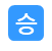
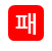
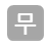
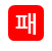
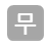
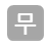
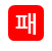
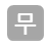
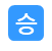
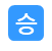
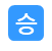
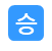
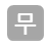
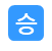
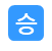
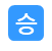
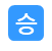
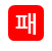
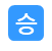
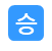
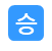
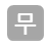
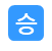
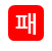
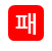
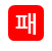
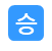
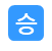
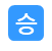
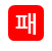
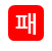
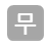
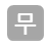
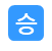
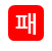
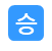
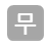
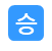
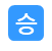
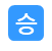
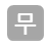
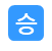
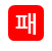
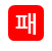
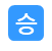
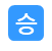
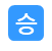
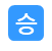
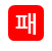
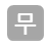
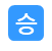
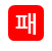
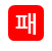
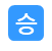
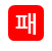
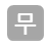
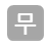
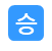
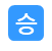
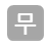
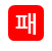
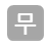
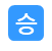
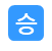
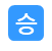
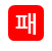
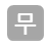
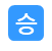
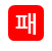
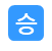
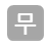
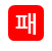
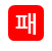
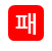
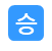
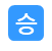
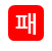
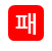
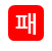
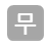
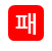
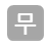
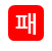
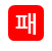
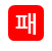
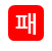
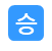
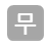
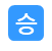
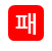
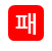
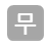
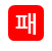
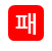
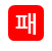
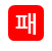
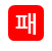
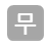
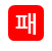
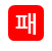

In [42]:
## P297
GT_table = (GT_table.fmt_image(columns="logoURL")
    .cols_align(align='center')
    .fmt_image(columns=['g1', 'g2', 'g3', 'g4', 'g5']))
GT_table

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    
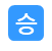
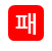
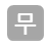
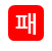
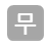
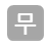
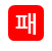
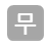
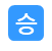
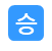
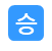
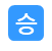
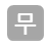
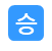
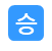
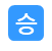
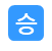
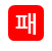
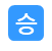
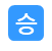
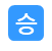
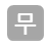
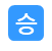
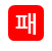
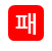
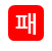
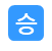
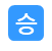
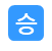
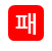
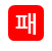
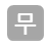
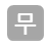
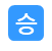
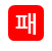
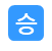
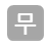
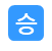
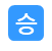
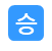
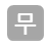
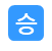
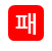
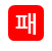
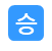
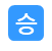
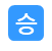
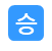
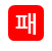
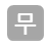
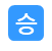
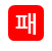
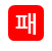
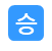
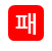
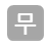
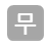
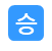
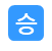
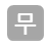
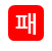
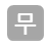
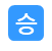
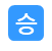
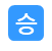
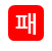
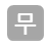
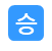
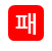
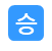
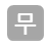
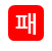
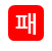
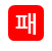
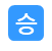
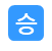
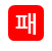
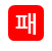
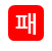
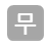
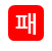
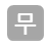
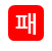
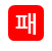
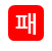
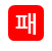
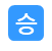
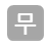
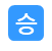
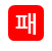
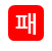
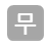
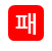
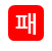
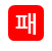
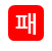
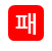
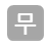
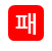
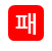

In [43]:
## P299
GT_table = (GT_table.tab_style(
    style = style.text(color = 'blue', weight = 'bold'),
    locations = loc.body(columns= ['teamRank', '팀'], rows = [0, 1, 2, 3]))
    .tab_style(
        style=style.text(color = 'orange', weight = 'bold'),
        locations=loc.body(columns= ['teamRank', '팀'], rows = [4]))
    .tab_style(
        style=style.text(color = 'red', weight = 'bold'),
        locations=loc.body(columns= ['teamRank', '팀'], rows = [17, 18, 19]))
    .tab_style(
        style=style.fill(color = 'lightcyan'),
        locations=loc.body(columns= '승점'))
)
GT_table

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    
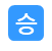
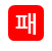
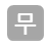
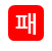
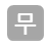
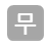
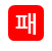
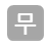
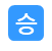
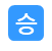
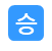
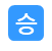
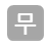
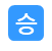
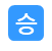
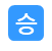
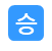
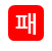
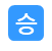
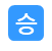
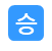
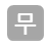
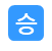
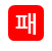
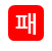
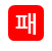
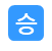
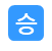
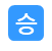
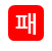
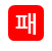
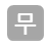
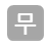
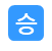
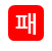
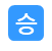
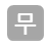
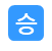
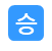
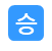
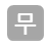
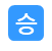
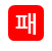
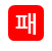
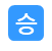
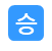
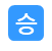
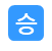
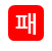
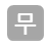
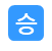
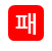
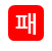
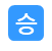
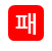
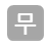
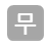
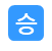
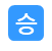
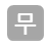
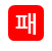
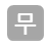
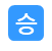
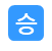
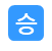
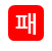
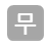
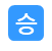
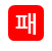
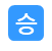
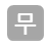
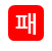
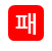
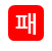
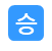
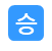
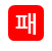
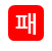
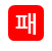
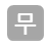
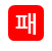
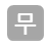
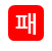
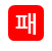
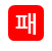
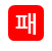
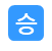
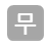
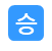
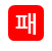
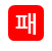
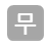
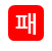
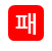
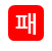
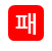
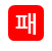
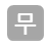
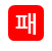
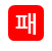

In [44]:
## P301
GT_table = (GT_table
    .tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('득점'),
        rows=(pl.col("득점") == ranking_table.aggregate("max(득점)")
            .fetchall()[0][0])))
    .tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('실점'),
        rows=(pl.col("실점") == ranking_table.aggregate("min(실점)")
            .fetchall()[0][0])))
.    tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('득실차'),
        rows=(pl.col("득실차") == ranking_table.aggregate("max(득실차)")
            .fetchall()[0][0])))
    .tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('총어시스트'),
        rows=(pl.col("총어시스트") == ranking_table.aggregate("max(총어시스트)")
            .fetchall()[0][0])))
.    tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('총유효슛'),
        rows=(pl.col("총유효슛") == ranking_table.aggregate("max(총유효슛)")
            .fetchall()[0][0])))
    .tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('경기당득점'),
        rows=(pl.col("경기당득점") == ranking_table.aggregate("max(경기당득점)")
            .fetchall()[0][0])))
    .tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('경기당실점'),
        rows=(pl.col("경기당실점") == ranking_table.aggregate("min(경기당실점)")
            .fetchall()[0][0])))
    .tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('경기당유효슛'),
        rows=(pl.col("경기당유효슛") == ranking_table.aggregate("max(경기당유효슛)")
            .fetchall()[0][0])))
    .tab_style(style=style.text(weight = 'bold'),
        locations=loc.body(columns = pl.col('득점당유효슛'),
        rows=(pl.col("득점당유효슛") == ranking_table.aggregate("min(득점당유효슛)")
            .fetchall()[0][0])))
)
GT_table

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    
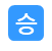
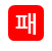
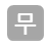
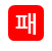
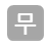
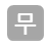
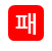
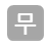
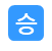
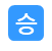
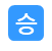
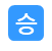
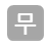
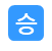
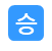
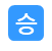
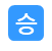
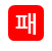
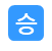
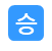
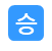
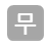
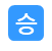
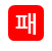
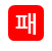
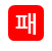
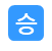
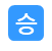
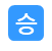
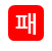
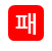
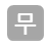
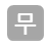
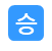
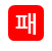
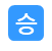
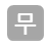
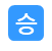
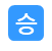
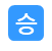
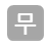
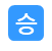
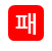
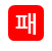
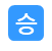
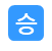
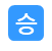
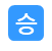
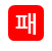
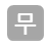
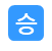
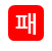
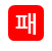
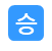
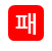
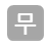
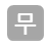
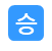
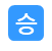
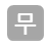
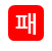
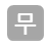
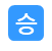
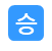
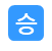
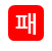
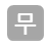
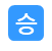
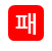
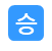
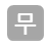
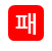
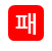
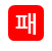
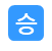
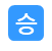
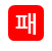
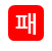
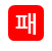
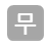
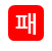
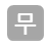
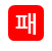
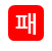
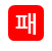
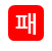
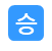
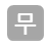
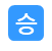
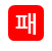
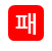
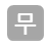
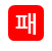
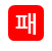
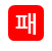
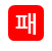
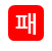
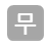
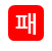
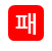

In [45]:
## P304
max_goal = ranking_rel.aggregate("max(gf)").fetchall()[0][0]
min_goal = ranking_rel.aggregate("min(gf)").fetchall()[0][0]
max_goal_against = ranking_rel.aggregate("max(ga)").fetchall()[0][0]
min_goal_against = ranking_rel.aggregate("min(ga)").fetchall()[0][0]
GT_table = (GT_table
    .data_color(columns='득점', palette = 'Greens', 
        domain = [min_goal, max_goal])
    .data_color(columns='실점', palette = 'Reds', 
        domain = [max_goal_against, min_goal_against]))
GT_table

GT(_tbl_data=shape: (20, 22)
┌──────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬─────────┐
│ teamRank ┆ logoURL  ┆ 팀       ┆ 경기수 ┆ … ┆ g2       ┆ g3       ┆ g4       ┆ g5      │
│ ---      ┆ ---      ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i64      ┆ str      ┆ str      ┆ i64    ┆   ┆ str      ┆ str      ┆ str      ┆ str     │
╞══════════╪══════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪═════════╡
│ 1        ┆ https:// ┆ Liverpoo ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ l        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 2        ┆ https:// ┆ Arsenal  ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 3        ┆ https:// ┆ Manchest ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆ er City  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 4        ┆ https:// ┆ Chelsea  ┆ 38     ┆ … ┆ win.png  ┆ lose.png ┆ win.png  ┆ win.png │
│          ┆ a.espncd ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 5        ┆ https:// ┆ Newcastl ┆ 38     ┆ … ┆ draw.png ┆ win.png  ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ e United ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ …        ┆ …        ┆ …        ┆ …      ┆ … ┆ …        ┆ …        ┆ …        ┆ …       │
│ 16       ┆ https:// ┆ Wolverha ┆ 38     ┆ … ┆ lose.png ┆ lose.png ┆ lose.png ┆ draw.pn │
│          ┆ a.espncd ┆ mpton    ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Wanderer ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆ s        ┆        ┆   ┆          ┆          ┆          ┆         │
│ 17       ┆ https:// ┆ Tottenha ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ m        ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆ Hotspur  ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 18       ┆ https:// ┆ Leiceste ┆ 38     ┆ … ┆ win.png  ┆ draw.png ┆ win.png  ┆ lose.pn │
│          ┆ a.espncd ┆ r City   ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 19       ┆ https:// ┆ Ipswich  ┆ 38     ┆ … ┆ draw.png ┆ lose.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ Town     ┆        ┆   ┆          ┆          ┆          ┆ g       │
│          ┆ n.com/i/ ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│          ┆ teamlo…  ┆          ┆        ┆   ┆          ┆          ┆          ┆         │
│ 20       ┆ https:// ┆ Southamp ┆ 38     ┆ … ┆ lose.png ┆ draw.png ┆ lose.png ┆ lose.pn │
│          ┆ a.espncd ┆ ton      ┆        ┆   ┆          ┆    
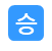
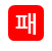
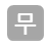
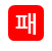
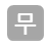
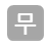
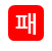
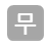
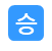
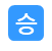
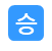
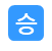
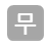
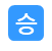
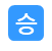
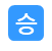
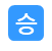
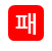
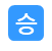
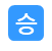
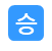
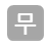
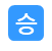
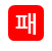
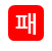
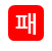
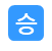
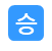
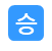
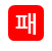
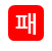
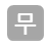
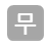
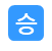
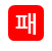
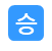
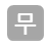
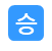
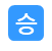
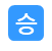
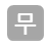
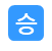
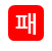
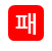
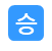
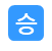
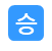
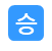
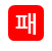
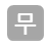
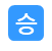
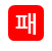
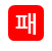
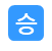
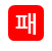
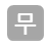
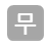
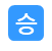
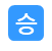
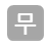
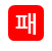
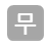
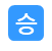
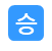
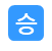
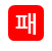
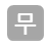
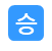
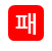
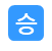
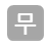
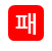
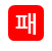
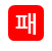
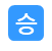
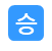
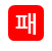
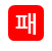
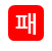
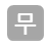
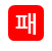
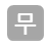
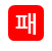
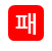
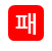
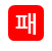
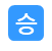
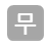
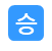
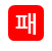
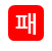
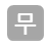
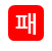
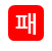
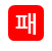
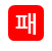
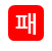
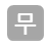
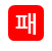
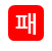

In [46]:
## P306
GT_table.tab_source_note(source_note=html("""
<div style='color:blue'>프리미어리그 1~4위인 팀은 UEFA 챔피언스리그 출전 자격을 얻는다.<BR>
<div style='color:orange'>프리미어리그 5위인 팀은 UEFA 유로파리그 출전 자격을 얻는다(컵 대회 결과에 따라 차순위 팀 자격 획득).<BR>
<div style='color:red'>프리미어리그 18~20위인 팀은 2부 리그로 강등된다."""))

In [47]:
## PP307
import polars as pl
import plotly.graph_objects as go
import plotly.express as px

In [48]:
## P308
playerName = "Erling Haaland"
goals_player = con_espn.execute("""
    with base_table as (from keyEvents_2024_EPL
        join keyEventDescription using (keyEventTypeId)
        join teamroster using (athleteId)
        join fixtures using (eventId)
        join teams as away on (away.teamId = fixtures.awayTeamId)
        join teams as home on (home.teamId = fixtures.homeTeamId)
        select eventId, playId, keyEventName, fieldPositionX, fieldPositionY,
            date::date as play_date, teamName, home.displayName as hometeam,
            away.displayName as awayteam
        where scoringPlay = 1 and participantOrder = 1 and
            teamroster.playerDisplayName = ? and
            teamRoster.seasonType = 12654) -- 여기까지 CTE 정의 부분
        from base_table
        select *, case when(hometeam != teamName) then hometeam
            else awayteam end as opposite;
    """, [playerName]).pl()
goals_player

eventId,playId,keyEventName,fieldPositionX,fieldPositionY,play_date,teamName,hometeam,awayteam,opposite
i64,i64,str,f64,f64,date,str,str,str,str
704381,44181471,"""Goal""",0.06,0.47,2024-11-09,"""Manchester City""","""Brighton & Hove Albion""","""Manchester City""","""Brighton & Hove Albion"""
704515,44622718,"""Goal - Header""",0.102,0.468,2025-02-02,"""Manchester City""","""Arsenal""","""Manchester City""","""Arsenal"""
704287,43577605,"""Goal""",0.148,0.464,2024-08-18,"""Manchester City""","""Chelsea""","""Manchester City""","""Chelsea"""
704540,44772868,"""Goal""",0.136,0.498,2025-02-26,"""Manchester City""","""Tottenham Hotspur""","""Manchester City""","""Tottenham Hotspur"""
704650,45318943,"""Penalty - Scored""",0.23,0.5,2025-05-25,"""Manchester City""","""Fulham""","""Manchester City""","""Fulham"""
…,…,…,…,…,…,…,…,…,…
704474,44481398,"""Goal""",0.2,0.429,2025-01-04,"""Manchester City""","""Manchester City""","""West Ham United""","""West Ham United"""
704502,44570863,"""Goal""",0.386,0.783,2025-01-25,"""Manchester City""","""Manchester City""","""Chelsea""","""Chelsea"""
704325,43822027,"""Goal""",0.264,0.605,2024-09-22,"""Manchester City""","""Manchester City""","""Arsenal""","""Arsenal"""


In [49]:
## P309
from PIL import Image
fig = go.Figure()
fig.update_layout(
    images=[dict(
        source=Image.open('half_stadium.png'),
        xref="x", yref="y", x=-10, y=130, sizex=160, sizey=140,
        sizing="stretch", layer="below")],
    xaxis=dict(range=[-10, 150], showgrid=False, zeroline=True, showticklabels=False),
    yaxis=dict(range=[-10, 130], showgrid=False, zeroline=True, showticklabels=False),
    plot_bgcolor='white', height=600, width=900,
    title="Goal Map : " + playerName)
fig.show()

In [50]:
## P310
def scale_X(X_list):
    return [140 - (X * 140) for X in X_list]
def scale_Y(Y_list):
    return [(X * 100) for X in Y_list]

In [51]:
## P311
fig = px.scatter(goals_player, y = scale_Y(goals_player['fieldPositionX']),
    x = scale_X(goals_player['fieldPositionY']),
    color='keyEventName', custom_data= ["opposite", 'play_date'],
    color_discrete_map={"Penalty - Scored": "red", "Goal - Header": "lightblue",
        "Goal - Free-kick": "black", "Goal" : "whitesmoke", 
        "Goal - Volley" : "darkgray"})
fig.update_traces(hovertemplate = "<b>상대팀:%{customdata[0]}</b><br>" +
    "<b>경기일:%{customdata[1]}</b><br><br>" +
    "<extra></extra>", mode='markers')

In [52]:
## P312
fig.update_layout(
    images=[dict(
        source=Image.open('half_stadium.png'),
        xref="x", yref="y", x=-10, y=130, sizex=160, sizey=140,
        sizing="stretch", layer="below")],
    xaxis=dict(range=[-10, 150], showgrid=False, zeroline=False, 
        showticklabels=False, title = None),
    yaxis=dict(range=[-10, 130], showgrid=False, zeroline=False, 
        showticklabels=False, title = None),
    plot_bgcolor='white', height=600, width=900,
    title="Goal Map : " + playerName,
    legend=dict(
        title=dict(text='골타입'), # 범례 제목
        bgcolor='green', # 범례 배경색
        font=dict(color='white')))
fig.show()

In [53]:
## P312
playerName = "Erling Haaland"
goals_player = con_espn.execute("""
    with base_table as (from keyEvents_2024_EPL
        join keyEventDescription using (keyEventTypeId)
        join teamroster using (athleteId)
        join fixtures using (eventId)
        join teams as away on (away.teamId = fixtures.awayTeamId)
        join teams as home on (home.teamId = fixtures.homeTeamId)
        select eventId, playId, keyEventName, fieldPositionX, fieldPositionY, 
            fieldPosition2X, fieldPosition2Y,
             date::date as play_date, teamName, home.displayName as hometeam,
             away.displayName as awayteam
        where scoringPlay = 1 and participantOrder = 1 and
            teamroster.playerDisplayName = ? and
            teamRoster.seasonType = 12654) -- 여기까지 CTE 정의 부분
        from base_table
        select *, case when(hometeam != teamName) then hometeam
            else awayteam end as opposite; """, [playerName]).pl()
def scale_X(X_list):
    return [140 - (X * 140) for X in X_list]
def scale_Y(Y_list):
    return [(X * 100) for X in Y_list]
fig = px.scatter(goals_player, y = scale_Y(goals_player['fieldPositionX']),
    x = scale_X(goals_player['fieldPositionY']),
    color='keyEventName', custom_data= ["opposite", 'play_date'],
    color_discrete_map={"Penalty - Scored": "red", "Goal - Header": "lightblue",
        "Goal - Free-kick": "black", "Goal" : "whitesmoke",
            "Goal - Volley" : "darkgray"})
fig.update_traces(
    hovertemplate = "<b>상대팀:%{customdata[0]}</b><br>" +
        "<b>경기일:%{customdata[1]}</b><br><br>" +
        "<extra></extra>", mode='markers')
fig.update_layout(
    images=[dict(
        source=Image.open('half_stadium.png'),
        xref="x", yref="y", x=-10, y=130, sizex=160, sizey=140,
        sizing="stretch", layer="below")],
    xaxis=dict(range=[-10, 150], showgrid=False, zeroline=False, 
        showticklabels=False, title = None),
    yaxis=dict(range=[-10, 130], showgrid=False, zeroline=False, 
        showticklabels=False, title = None),
    plot_bgcolor='white', height=600, width=900,
    title="Goal Map : " + playerName,
    legend=dict(
        title=dict(text='골타입'), # 범례 제목
        bgcolor='green', # 범례 배경색
        font=dict(color='white')))
fig.show()

In [54]:
con_espn.close()